In [1]:
from pathlib import Path

import pandas as pd

In [9]:
project_root = Path.cwd().parent

csv_path = project_root / "data" / "raw" / "spy.csv"

df = pd.read_csv(csv_path)

In [12]:
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2000-01-03,91.132729,145.4375,148.25000,143.875000,148.25000,8164300
2000-01-04,87.568855,139.7500,144.06250,139.640625,143.53125,8089800
2000-01-05,87.725548,140.0000,141.53125,137.250000,139.93750,12177900
2000-01-06,86.315651,137.7500,141.50000,137.750000,139.62500,6227200
2000-01-07,91.328590,145.7500,145.75000,140.062500,140.31250,8066500


In [11]:
df = df.set_index("Date")

In [7]:
with open(csv_path, "r") as f:
    for _ in range(15):
        print(f.readline(), end="")

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2000-01-03,91.13275909423828,145.4375,148.25,143.875,148.25,8164300
2000-01-04,87.56890869140625,139.75,144.0625,139.640625,143.53125,8089800
2000-01-05,87.72554016113281,140.0,141.53125,137.25,139.9375,12177900
2000-01-06,86.31564331054688,137.75,141.5,137.75,139.625,6227200
2000-01-07,91.32852935791016,145.75,145.75,140.0625,140.3125,8066500
2000-01-10,91.6418685913086,146.25,146.90625,145.03125,146.25,5741700
2000-01-11,90.54529571533203,144.5,146.09375,143.5,145.8125,7503700
2000-01-12,89.64453887939453,143.0625,144.59375,142.875,144.59375,6907700
2000-01-13,90.85860443115234,145.0,145.75,143.28125,144.46875,5158300
2000-01-14,92.09227752685547,146.96875,147.46875,145.96875,146.53125,7437300
2000-01-18,91.36770629882812,145.8125,146.625,145.1875,145.34375,6488500
2000-01-19,92.11184692382812,147.0,147.0,145.0,145.3125,6157900


In [8]:
df.shape

(6662, 7)

In [13]:
df.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [14]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,6660.000000,6660.000000,6660.000000,6660.000000,6660.000000,6.660000e+03
mean,204.629172,235.362532,236.688403,233.863460,235.339343,1.042273e+08
std,165.219803,156.992617,157.679335,156.149529,156.954896,8.898695e+07
min,49.680580,68.110001,70.000000,67.099998,67.949997,1.436600e+06
25%,84.816578,121.589996,122.397501,120.900002,121.645000,5.074380e+07
50%,124.246288,156.110001,156.459999,155.220001,156.024994,7.754235e+07
75%,268.829353,296.514992,297.990005,294.514992,296.707497,1.303685e+08
max,757.618225,759.570007,760.400024,756.750000,758.150024,8.710263e+08


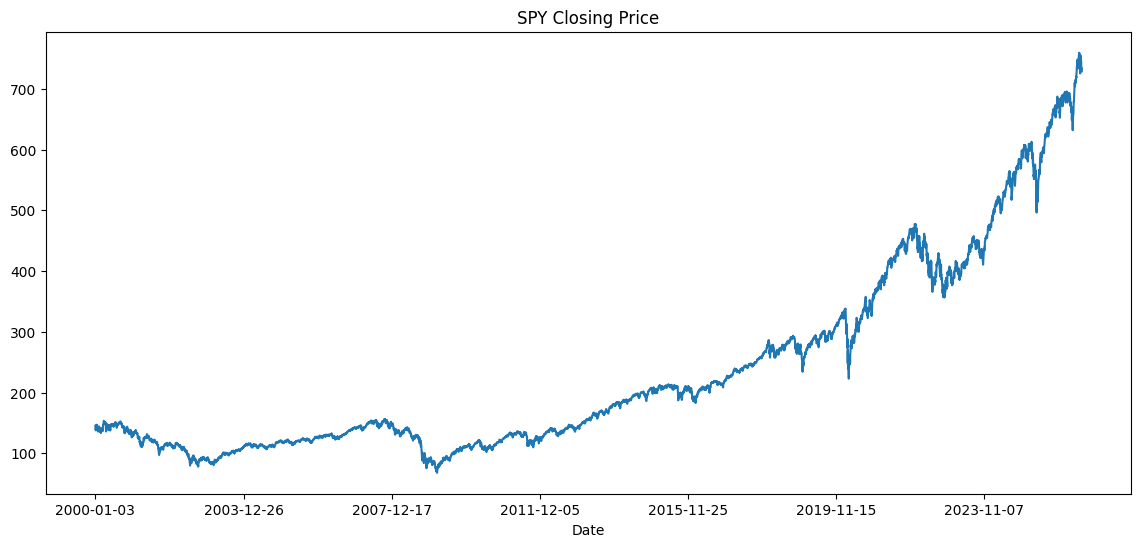

In [23]:
import matplotlib.pyplot as plt

df["Close"].plot(figsize=(14,6))

plt.title("SPY Closing Price")
plt.show()

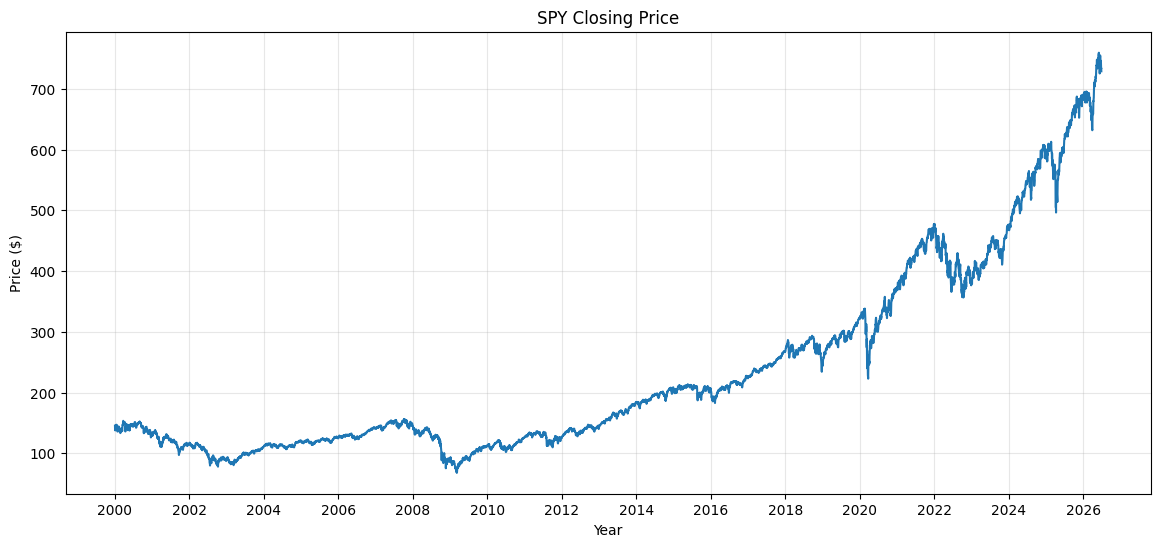

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"])

ax.set_title("SPY Closing Price")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($)")

ax.xaxis.set_major_locator(mdates.YearLocator(2))   # Every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)

plt.show()

In [24]:
df["Daily Return"] = df["Close"].pct_change()

<Axes: xlabel='Date'>

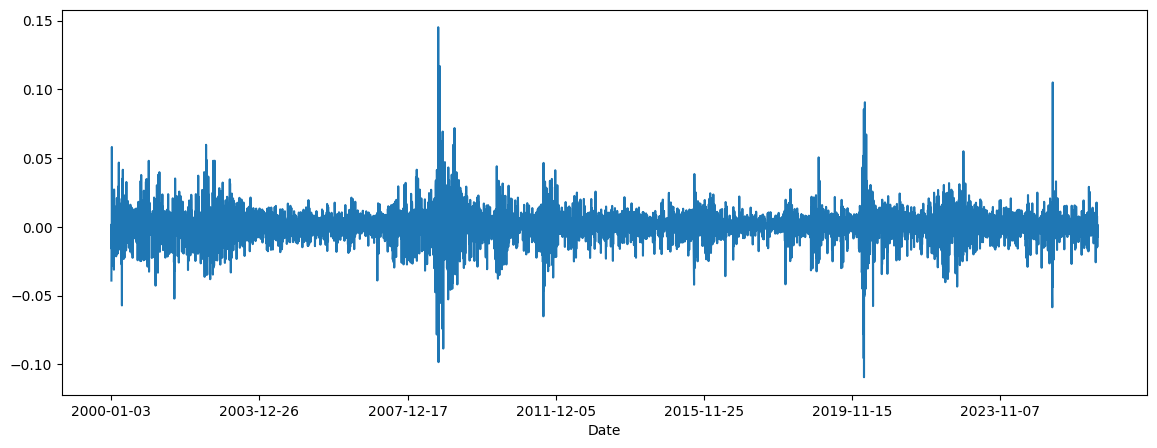

In [25]:
df["Daily Return"].plot(figsize=(14,5))

<Axes: >

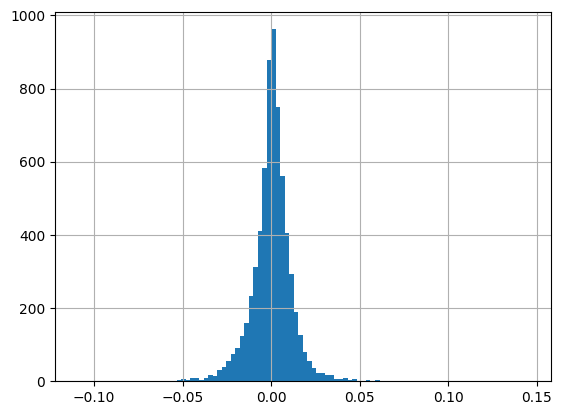

In [26]:
df["Daily Return"].hist(bins=100)

In [27]:
df["Volatility20"] = (
    df["Daily Return"]
      .rolling(20)
      .std()
)

<Axes: xlabel='Date'>

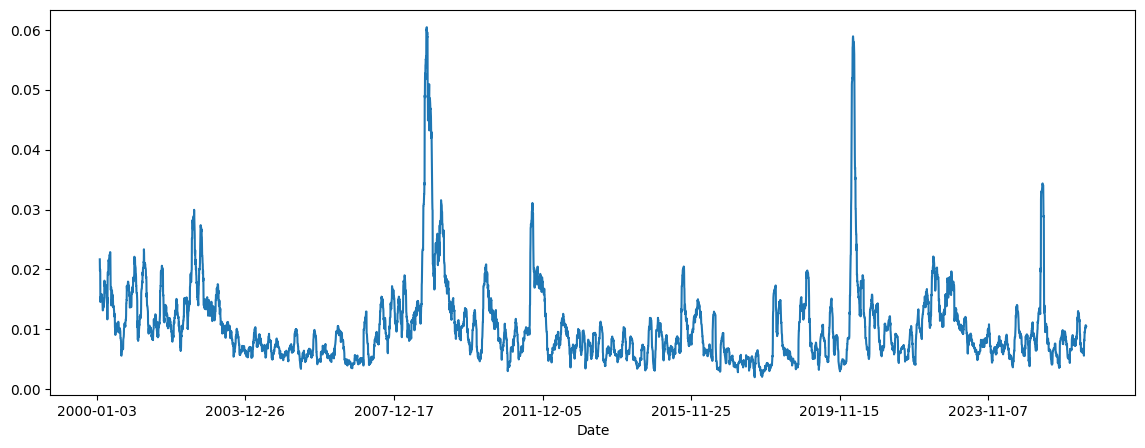

In [28]:
df["Volatility20"].plot(figsize=(14,5))

In [29]:
df["SMA20"] = df["Close"].rolling(20).mean()
df["SMA50"] = df["Close"].rolling(50).mean()
df["SMA200"] = df["Close"].rolling(200).mean()

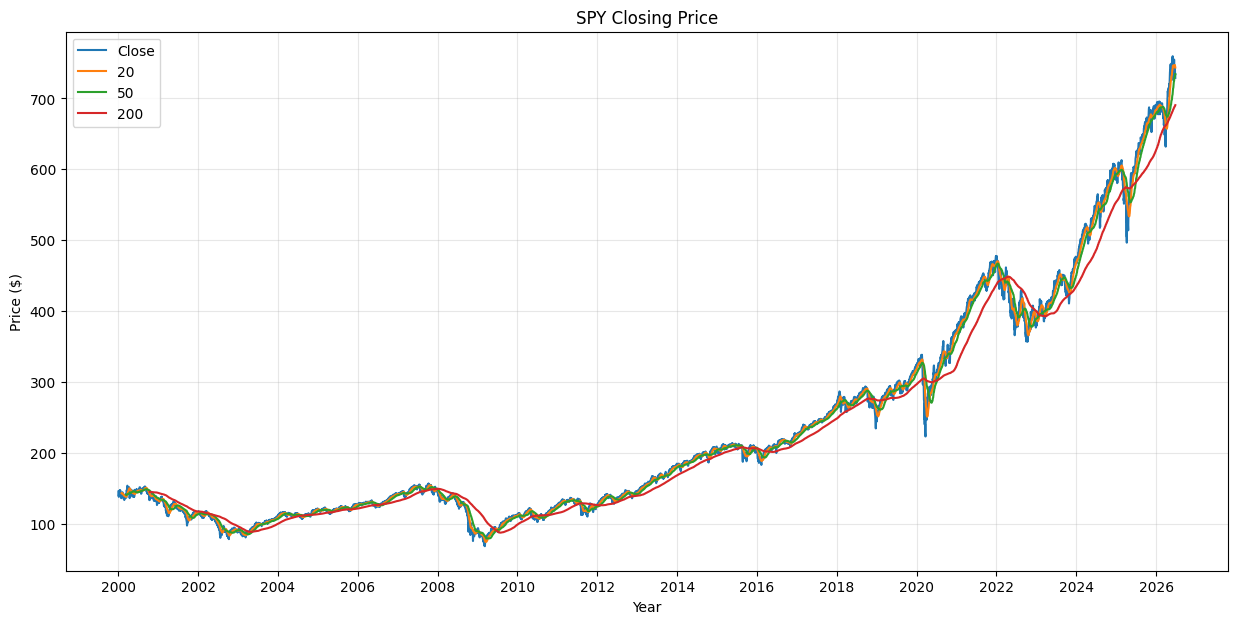

In [38]:
fig, ax = plt.subplots(figsize=(15, 7))



ax.plot(df.index, df["Close"], label="Close")
ax.plot(df.index, df["SMA20"], label="20")
ax.plot(df.index, df["SMA50"], label="50")
ax.plot(df.index, df["SMA200"], label="200")

ax.set_title("SPY Closing Price")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($)")

ax.xaxis.set_major_locator(mdates.YearLocator(2))   # Every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [31]:
df["Daily Return"].idxmin()

'2020-03-16'

In [36]:
df.index = pd.to_datetime(df.index)